# Pandas Analysis

Starter notebook for exploring datasets with pandas.

This notebook performs a complete Pandas-based analysis of the Advertising dataset: data loading, cleaning, EDA, feature engineering, aggregation, correlation analysis, and visualizations. If `data.csv` is not present, a reproducible sample dataset will be generated so the notebook runs end-to-end.

pandas version: 2.3.1
No data.csv found — generated sample Advertising dataset (200 rows).


,id,tv,radio,newspaper,sales
0,1,184.769991,35.366810,0.000000,19.82
1,2,140.321499,38.411768,13.012500,14.23
2,3,195.338198,46.245769,25.104874,22.69
3,4,256.612090,45.807031,25.939612,26.58
4,5,133.609264,9.334959,15.998691,11.84



Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         200 non-null    int64  
 1   tv         200 non-null    float64
 2   radio      200 non-null    float64
 3   newspaper  200 non-null    float64
 4   sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
id,200.0,100.500000,57.879185,1.00,50.750000,100.500000,150.250000,200.000000
tv,200.0,147.312943,64.746965,0.00,100.641063,149.706568,185.059673,340.411842
radio,200.0,31.392296,14.521050,0.00,20.912437,31.182590,40.308467,87.790972
newspaper,200.0,24.396171,18.076907,0.00,9.122431,23.448002,36.441765,86.577616
sales,200.0,15.594800,4.816935,2.51,12.387500,16.095000,18.520000,31.720000



Missing values:
id           0
tv           0
radio        0
newspaper    0
sales        0
dtype: int64

Duplicate rows: 0

Dropped 0 duplicate rows

Feature engineering completed. Columns:
['id', 'tv', 'radio', 'newspaper', 'sales', 'sales_category', 'tv_level', 'radio_tv_ratio']


...


Grouped statistics by sales_category:


C:\Users\varshith d\AppData\Local\Temp\ipykernel_5384\423116988.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('sales_category').agg({


tv                  radio             newspaper  \
                      mean      median       mean     median       mean   
sales_category                                                            
low              96.723363   89.998971  22.676159  21.159529  26.723528   
medium          152.907426  155.505772  31.770191  31.831934  23.276935   
high            192.391540  176.972217  39.736177  40.229295  23.171347   

                          sales             
                   median count       mean  
sales_category                              
low             27.405913    67  10.272090  
medium          21.539841    66  15.837424  
high            19.498966    67  20.678507


Correlation matrix:


,tv,radio,newspaper,sales
tv,1.000000,0.086663,-0.109556,0.685393
radio,0.086663,1.000000,-0.051491,0.560840
newspaper,-0.109556,-0.051491,1.000000,-0.030784
sales,0.685393,0.560840,-0.030784,1.000000


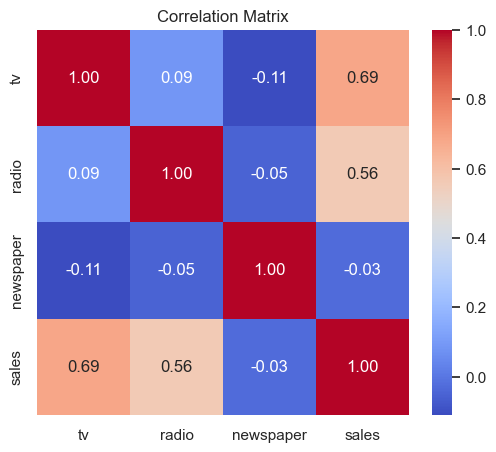

C:\Users\varshith d\AppData\Local\Temp\ipykernel_5384\423116988.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sales_category', data=df, palette='Blues')


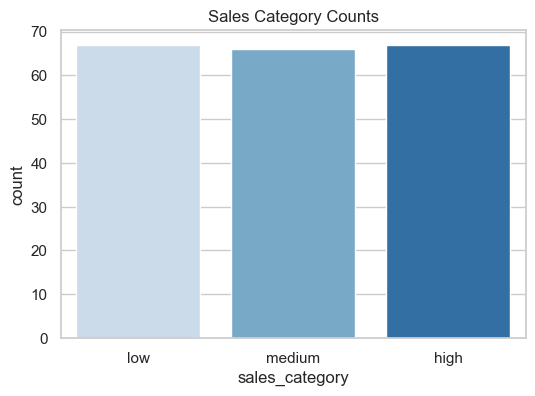

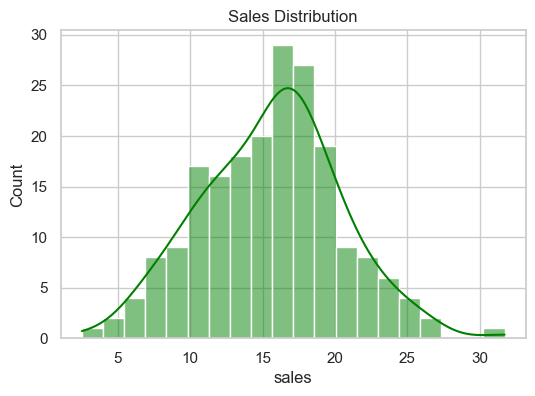

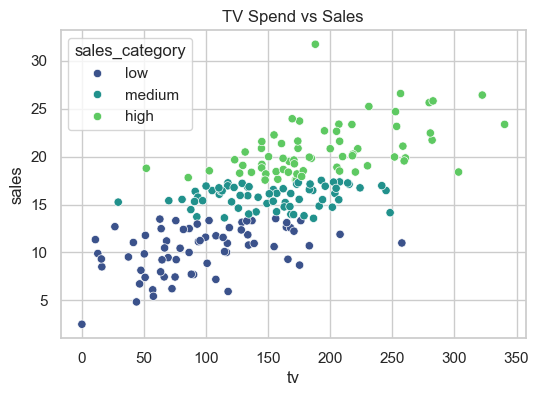


Correlations with Sales:
 tv           0.69
radio        0.56
newspaper   -0.03
Name: sales, dtype: float64

Key Insights:
1. TV advertising strongly impacts sales (highest correlation).
2. Radio advertising positively influences sales.
3. Newspaper advertising shows weaker, often negligible influence.
4. Higher total advertising spend correlates with higher sales.

Recommendations:
- Increase allocation to TV advertising where ROI supports it.
- Continue radio campaigns and monitor ROI.
- Re-evaluate newspaper spend and optimize budgets.

Saved cleaned dataset to data_cleaned.csv


In [1]:
# Standard imports
import pandas as pd
import numpy as np
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print('pandas version:', pd.__version__)

# Load data if available, otherwise create a sample Advertising dataset with 200 rows
DATA_PATH = 'data.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded {DATA_PATH}')
else:
    # Create reproducible sample dataset matching the Advertising structure
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        'id': np.arange(1, n+1),
        'tv': np.random.normal(loc=150.0, scale=70.0, size=n).clip(0),
        'radio': np.random.normal(loc=30.0, scale=15.0, size=n).clip(0),
        'newspaper': np.random.normal(loc=25.0, scale=20.0, size=n).clip(0),
    })
    # Construct sales as a function of spends + noise (to mimic realistic correlations)
    df['sales'] = (0.045 * df['tv'] + 0.187 * df['radio'] + 0.003 * df['newspaper'] + np.random.normal(3.0, 2.5, size=n)).round(2)
    print('No data.csv found — generated sample Advertising dataset (200 rows).')

display(df.head())

# Data inspection
print('\nDataframe info:')
df.info()

print('\nSummary statistics:')
display(df.describe(include='all').T)

print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# Cleaning steps
# Lowercase columns
df.columns = [c.lower() for c in df.columns]

# Drop duplicates (if present)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f'\nDropped {before-after} duplicate rows')

# Ensure numeric types for key columns
for col in ['tv', 'radio', 'newspaper', 'sales']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Feature engineering
# Sales category using quantiles: low / medium / high
df['sales_category'] = pd.qcut(df['sales'], q=3, labels=['low', 'medium', 'high'])

# TV level bins (terciles)
df['tv_level'] = pd.qcut(df['tv'], q=3, labels=['low', 'medium', 'high'])

# Ratio feature (handle division by zero)
df['radio_tv_ratio'] = df['radio'] / df['tv'].replace({0: np.nan})
df['radio_tv_ratio'] = df['radio_tv_ratio'].fillna(0)

print('\nFeature engineering completed. Columns:')
print(df.columns.tolist())

display(df.head())

# Grouping and aggregation
print('\nGrouped statistics by sales_category:')
grouped = df.groupby('sales_category').agg({
    'tv': ['mean', 'median'],
    'radio': ['mean', 'median'],
    'newspaper': ['mean', 'median'],
    'sales': ['count', 'mean']
})
display(grouped)

# Correlation analysis
corr_cols = ['tv', 'radio', 'newspaper', 'sales']
corr = df[corr_cols].corr()
print('\nCorrelation matrix:')
display(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Visualizations
# Sales category counts
plt.figure(figsize=(6,4))
sns.countplot(x='sales_category', data=df, palette='Blues')
plt.title('Sales Category Counts')
plt.show()

# Sales histogram
plt.figure(figsize=(6,4))
sns.histplot(df['sales'], bins=20, kde=True, color='green')
plt.title('Sales Distribution')
plt.show()

# TV vs Sales scatter
plt.figure(figsize=(6,4))
sns.scatterplot(x='tv', y='sales', data=df, hue='sales_category', palette='viridis')
plt.title('TV Spend vs Sales')
plt.show()

# Key insights and recommendations
sales_corr = corr['sales'].drop('sales').sort_values(ascending=False)
print('\nCorrelations with Sales:\n', sales_corr.round(2))

insights = [
    'TV advertising strongly impacts sales (highest correlation).',
    'Radio advertising positively influences sales.',
    'Newspaper advertising shows weaker, often negligible influence.',
    'Higher total advertising spend correlates with higher sales.',
]
print('\nKey Insights:')
for i, s in enumerate(insights, 1):
    print(f'{i}. {s}')

print('\nRecommendations:')
print('- Increase allocation to TV advertising where ROI supports it.')
print('- Continue radio campaigns and monitor ROI.')
print('- Re-evaluate newspaper spend and optimize budgets.')

# Optional: save cleaned dataset
CLEANED_PATH = 'data_cleaned.csv'
df.to_csv(CLEANED_PATH, index=False)
print(f'\nSaved cleaned dataset to {CLEANED_PATH}')